In [22]:
#necessary imports

from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

# Example 1 is to find the roots of quadration equation.. There are three conditions: 
1. Both roots are real and same
2. Both roots are real and different
3. Roots are imaginary

In [2]:
class QuadraticEquationState(TypedDict):
    a: float
    b: float
    c: float
    equation: str
    discriminant: float
    result: str

In [3]:
def show_equation(state: QuadraticEquationState):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {
        "equation": equation
    }

In [4]:
def calculate_discriminant(state: QuadraticEquationState):
    discriminant = state['b']**2 - (4*state['a']*state['c'])
    return {
        "discriminant": discriminant
    }

In [7]:
def real_different_roots(state: QuadraticEquationState):
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    return {
        "result": f"The equation has two real and different roots: {root1} and {root2}"
    }


def real_equal_roots(state: QuadraticEquationState):
    root = -state['b'] / (2*state['a'])
    return {
        "result": f"The equation has two real and equal roots: {root}"
    }

def complex_roots(state: QuadraticEquationState):
    real_part = -state['b'] / (2*state['a'])
    imaginary_part = (abs(state['discriminant'])**0.5) / (2*state['a'])
    return {
        "result": f"The equation has two complex roots: {real_part} + {imaginary_part}i and {real_part} - {imaginary_part}i"
    }

In [13]:
# special function to imlement conditional branching in the workflow

def check_condition(state: QuadraticEquationState) -> Literal["real_different_roots", "real_equal_roots", "complex_roots"]:
    if state['discriminant'] > 0:
        return "real_different_roots"
    elif state['discriminant'] == 0:
        return "real_equal_roots"
    else:
        return "complex_roots"

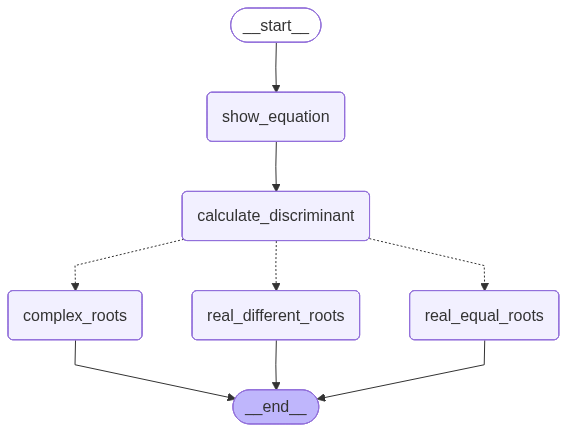

In [16]:

equation_graph  = StateGraph(QuadraticEquationState)

equation_graph.add_node("show_equation" , show_equation)
equation_graph.add_node("calculate_discriminant" , calculate_discriminant)
equation_graph.add_node("real_different_roots" , real_different_roots)
equation_graph.add_node("real_equal_roots" , real_equal_roots)
equation_graph.add_node("complex_roots" , complex_roots)



equation_graph.add_edge(START, "show_equation")
equation_graph.add_edge("show_equation", "calculate_discriminant")

# adding conditional edges based on the value of the discriminant
equation_graph.add_conditional_edges("calculate_discriminant", check_condition)
equation_graph.add_edge("real_different_roots", END)
equation_graph.add_edge("real_equal_roots", END)
equation_graph.add_edge("complex_roots", END)

equation_workflow = equation_graph.compile()
equation_workflow

In [20]:
initial_state = {
    "a" : 1,
    "b" : 6,
    "c" : 2
}
equation_workflow.invoke(initial_state)

{'a': 1,
 'b': 6,
 'c': 2,
 'equation': '1x^2 + 6x + 2 = 0',
 'discriminant': 28,
 'result': 'The equation has two real and different roots: -0.3542486889354093 and -5.645751311064591'}

# Example 1 is LLM based Conditional workflow.. Here we reply a review accorditing to the sentiment of review(positive or negative)

In [23]:
load_dotenv(override=True)

#we use gpt_4o_mini as it gives structured output..

model = ChatOpenAI(
    model="gpt-4o-mini", 
    api_key=os.getenv("github_OPENAI_KEY"), 
    base_url="https://models.inference.ai.azure.com" 
)



try:
    print("Testing Updated GitHub Token...")
    print("Response:", model.invoke("Hello!").content)
except Exception as e:
    print(f"Error: {e}")

Testing Updated GitHub Token...
Response: Hello! How can I assist you today?


In [24]:
#defining a schema for the output of the model to implement conditional branching based on the sentiment of the review

class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review") 

In [25]:
structured_model = model.with_structured_output(SentimentSchema)

In [31]:
class DiagnoseSchema(BaseModel):
    issue_type: Literal["UX Issue", "Performance Issue", "Security Issue","Bug Issue" ,"Other"] = Field(description="The type of issue diagnosed from the review")
    tone: Literal["angry" , "Frustrated" , "Disappointed" , "Calm"] = Field(description="The emotional tone expressed by the user in the review")
    urgency: Literal["Low" , "Medium" , "High"] = Field(description="The urgency of the issue based on the review")

In [32]:
structured_model_diagnose = model.with_structured_output(DiagnoseSchema)

In [26]:
prompt = "The movie was fantastic! I really enjoyed it."
structured_response = structured_model.invoke(prompt)
print(structured_response)

sentiment='positive'


c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=SentimentSchema(sentiment='positive'), input_type=SentimentSchema])
  return self.__pydantic_serializer__.to_python(


In [28]:
#State of Graph
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [34]:
def find_sentiment(state: ReviewState):
    prompt = f"Determine the sentiment of the following review: {state['review']}. Respond with 'positive' or 'negative'."
    response = structured_model.invoke(prompt)
    return {
        "sentiment": response.sentiment
    }



#conditional Function
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"
    

def positive_response(state: ReviewState):
    prompt = f"""Write a Thankyou message in response to the following review: {state['review']}\n
    Kindly ask the user to leave the feedback on our website.
    """

    response = model.invoke(prompt)
    return {
        "response": response.content
    }


def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose the following negative review and determine the issue type, emotional tone, and urgency: {state['review']}"""
    response = structured_model_diagnose.invoke(prompt)
    return {
        "diagnosis": response.model_dump()
    }

def negative_response(state: ReviewState):
    prompt = f"""You are a customer support agent.
        The user has a '{state['diagnosis']['issue_type']}' with a '{state['diagnosis']['tone']}' tone and '{state['diagnosis']['urgency']}' urgency based on their review.    
        Write a empathetic response acknowledging their concerns and outlining the steps you will take to address the issue.\n
    """

    response = model.invoke(prompt)
    return {
        "response": response.content
    }

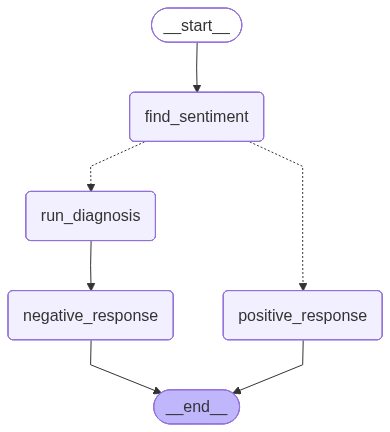

In [35]:
#makinng graph

review_graph = StateGraph(ReviewState)

review_graph.add_node("find_sentiment" , find_sentiment)
review_graph.add_node("positive_response" , positive_response)
review_graph.add_node("run_diagnosis" , run_diagnosis)
review_graph.add_node("negative_response" , negative_response)


review_graph.add_edge(START, "find_sentiment")
#conditional edges based on the sentiment of the review
review_graph.add_conditional_edges("find_sentiment", check_sentiment)
review_graph.add_edge("positive_response", END)
review_graph.add_edge("run_diagnosis", "negative_response")
review_graph.add_edge("negative_response", END)



review_workflow = review_graph.compile()
review_workflow

In [36]:
initial_state_for_positive = {
    "review": "I recently bought this product and I am very satisfied with it. The quality is excellent and it works exactly as described. It is easy to use and the design is also very nice. I have been using it for a few days and it performs very well without any issues. The price is also reasonable compared to the features it provides. I would definitely recommend this product to others.",
    
}

review_workflow.invoke(initial_state_for_positive)

c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=SentimentSchema(sentiment='positive'), input_type=SentimentSchema])
  return self.__pydantic_serializer__.to_python(


{'review': 'I recently bought this product and I am very satisfied with it. The quality is excellent and it works exactly as described. It is easy to use and the design is also very nice. I have been using it for a few days and it performs very well without any issues. The price is also reasonable compared to the features it provides. I would definitely recommend this product to others.',
 'sentiment': 'positive',
 'response': "Dear [Customer's Name],\n\nThank you so much for taking the time to share your positive experience with our product! We’re thrilled to hear that you are satisfied with the quality, ease of use, and design. Your feedback is incredibly valuable to us, and we appreciate your recommendation to others.\n\nIf you have a moment, we would be grateful if you could also share your feedback on our website. It helps us continue to improve and assists other customers in making informed decisions.\n\nThanks once again for your support!\n\nBest regards,  \n[Your Name]  \n[Your

In [37]:
initial_state_for_negative = {
    "review": "I bought this product but unfortunately my experience was not good. The quality is not as good as I expected and it does not work properly sometimes. The design looks fine but the performance is disappointing. I also think the price is a bit high for what it offers. Overall, I am not satisfied with this product and would not recommend it",
}
review_workflow.invoke(initial_state_for_negative)

c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=SentimentSchema(sentiment='negative'), input_type=SentimentSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DiagnoseSchema(issue_type...nted', urgency='Medium'), input_type=DiagnoseSchema])
  return self.__pydantic_serializer__.to_python(


{'review': 'I bought this product but unfortunately my experience was not good. The quality is not as good as I expected and it does not work properly sometimes. The design looks fine but the performance is disappointing. I also think the price is a bit high for what it offers. Overall, I am not satisfied with this product and would not recommend it',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Performance Issue',
  'tone': 'Disappointed',
  'urgency': 'Medium'},
 'response': "Subject: We're Here to Help with Your Performance Issue\n\nDear [User's Name],\n\nThank you for reaching out and sharing your experience with us. I’m truly sorry to hear that you’re facing performance issues, and I understand how disappointing this must be for you. Your satisfaction is very important to us, and we are committed to resolving this matter as quickly as possible.\n\nTo get started, I would like to gather some additional information regarding the specific performance issues you are encount